# Notebook 05: Platform Dominance Over Time

## Objective

This notebook examines how video game platform dominance changed over time.

Platform performance is evaluated using lifetime global sales, average annual sales, annual global sales, yearly market share, and the number of years each platform led the market. Using several measures avoids treating lifetime sales alone as evidence of dominance because platforms were active for different lengths of time and reached their peaks during different market periods.

The analysis identifies the largest platforms overall, compares their sales trajectories, determines the leading platform in each year, summarizes consecutive periods of leadership, and measures how strongly each annual leader controlled the market.

The broader implications, limitations, connections to the other research questions, and final conclusions will be developed in the final project report.

## Research Question

**How has platform dominance changed over time, and which platforms led the market during different periods?**

In [71]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")

In [73]:
candidate_paths = [
    Path("../../data/processed/video_game_sales_cleaned.csv"),
    Path("../data/processed/video_game_sales_cleaned.csv"),
    Path("data/processed/video_game_sales_cleaned.csv"),
]

data_path = next(
    (path for path in candidate_paths if path.exists()),
    None
)

if data_path is None:
    raise FileNotFoundError(
        "Could not find video_game_sales_cleaned.csv. "
        "Update candidate_paths to match the notebook's location."
    )

df = pd.read_csv(data_path)

print(f"Loaded: {data_path.resolve()}")
print(f"Dataset shape: {df.shape}")
df.head()

Loaded: C:\Users\tyler\OneDrive\Desktop\26projects\data_an\data-analysis-on-the-videogame-industry\data\processed\video_game_sales_cleaned.csv
Dataset shape: (16287, 19)


,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,regional_sales_total,decade,sales_tier,is_high_seller,na_sales_share,eu_sales_share,jp_sales_share,other_sales_share,dominant_region
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74,2000s,blockbuster,1,0.50,0.35,0.05,0.10,North America
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24,1980s,blockbuster,1,0.72,0.09,0.17,0.02,North America
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83,2000s,blockbuster,1,0.44,0.36,0.11,0.09,North America
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00,2000s,blockbuster,1,0.48,0.33,0.10,0.09,North America
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38,1990s,blockbuster,1,0.36,0.28,0.33,0.03,North America


In [74]:
required_columns = {
    "name",
    "platform",
    "year",
    "global_sales"
}

missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(
        f"The dataset is missing required columns: {sorted(missing_columns)}"
    )

df[list(required_columns)].info()

<class 'pandas.DataFrame'>
RangeIndex: 16287 entries, 0 to 16286
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          16287 non-null  str    
 1   year          16287 non-null  int64  
 2   platform      16287 non-null  str    
 3   global_sales  16287 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 509.1 KB


In [75]:
platform_df = (
    df.dropna(subset=["platform", "year", "global_sales"])
      .copy()
)

platform_df["year"] = platform_df["year"].astype(int)

print(f"Rows used in this analysis: {len(platform_df):,}")
print(
    f"Analysis period: {platform_df['year'].min()}–"
    f"{platform_df['year'].max()}"
)
print(f"Platforms represented: {platform_df['platform'].nunique()}")

Rows used in this analysis: 16,287
Analysis period: 1980–2016
Platforms represented: 31


### Check Potential Platform-Year Anomalies

A platform's first recorded year can be distorted by an incorrectly coded game year. The table below displays the earliest record for each platform so unusual values can be reviewed without silently changing the prepared dataset.

In [76]:
platform_first_records = (
    platform_df.loc[
        platform_df.groupby("platform")["year"].idxmin(),
        ["platform", "year", "name", "global_sales"]
    ]
    .sort_values("year")
    .reset_index(drop=True)
)

platform_first_records

,platform,year,name,global_sales
0,2600,1980,Asteroids,4.31
1,NES,1983,Baseball,3.20
2,PC,1985,Alter Ego,0.03
3,DS,1985,Strongest Tokyo University Shogi DS,0.02
4,GB,1988,Disney's DuckTales,1.43
5,GEN,1990,Streets of Rage,2.60
6,SNES,1990,Super Mario World,20.61
7,GG,1992,Sonic the Hedgehog 2 (8-bit),0.04
8,SCD,1993,Sonic CD,1.50
9,NG,1993,The King of Fighters '94 (CD),0.14


In [77]:
platform_year_sales = (
    platform_df.groupby(["year", "platform"], as_index=False)
               .agg(
                   global_sales=("global_sales", "sum"),
                   game_count=("name", "count")
               )
)

platform_year_sales.head()

,year,platform,global_sales,game_count
0,1980,2600,11.38,9
1,1981,2600,35.77,46
2,1982,2600,28.86,36
3,1983,2600,5.83,11
4,1983,NES,10.96,6


In [78]:
yearly_market_sales = (
    platform_year_sales.groupby("year", as_index=False)
                       .agg(
                           yearly_global_sales=("global_sales", "sum"),
                           yearly_game_count=("game_count", "sum")
                       )
)

yearly_market_sales.head()

,year,yearly_global_sales,yearly_game_count
0,1980,11.38,9
1,1981,35.77,46
2,1982,28.86,36
3,1983,16.79,17
4,1984,50.36,14


In [79]:
platform_market_share = platform_year_sales.merge(
    yearly_market_sales,
    on="year",
    how="left"
)

platform_market_share["market_share_pct"] = (
    platform_market_share["global_sales"]
    / platform_market_share["yearly_global_sales"]
    * 100
)

platform_market_share.head()

,year,platform,global_sales,game_count,yearly_global_sales,yearly_game_count,market_share_pct
0,1980,2600,11.38,9,11.38,9,100.00
1,1981,2600,35.77,46,35.77,46,100.00
2,1982,2600,28.86,36,28.86,36,100.00
3,1983,2600,5.83,11,16.79,17,34.72
4,1983,NES,10.96,6,16.79,17,65.28


In [80]:
yearly_platform_leaders = (
    platform_market_share.loc[
        platform_market_share.groupby("year")["global_sales"].idxmax()
    ]
    .sort_values("year")
    .reset_index(drop=True)
)

yearly_platform_leaders = yearly_platform_leaders[
    [
        "year",
        "platform",
        "global_sales",
        "yearly_global_sales",
        "market_share_pct",
        "game_count"
    ]
]

yearly_platform_leaders.head()

,year,platform,global_sales,yearly_global_sales,market_share_pct,game_count
0,1980,2600,11.38,11.38,100.00,9
1,1981,2600,35.77,35.77,100.00,46
2,1982,2600,28.86,28.86,100.00,36
3,1983,NES,10.96,16.79,65.28,6
4,1984,NES,50.09,50.36,99.46,13


In [81]:
platform_lifecycle = (
    platform_year_sales.groupby("platform", as_index=False)
                       .agg(
                           first_year=("year", "min"),
                           last_year=("year", "max"),
                           active_years=("year", "nunique"),
                           lifetime_global_sales=("global_sales", "sum"),
                           average_annual_sales=("global_sales", "mean"),
                           peak_annual_sales=("global_sales", "max")
                       )
)

platform_lifecycle["recorded_year_span"] = (
    platform_lifecycle["last_year"]
    - platform_lifecycle["first_year"]
    + 1
)

In [82]:
platform_peak_years = (
    platform_year_sales.loc[
        platform_year_sales.groupby("platform")["global_sales"].idxmax()
    ]
    .rename(
        columns={
            "year": "peak_year",
            "global_sales": "peak_year_sales",
            "game_count": "peak_year_game_count"
        }
    )
    .reset_index(drop=True)
)

platform_summary = (
    platform_lifecycle.merge(
        platform_peak_years,
        on="platform",
        how="left"
    )
    [
        [
            "platform",
            "first_year",
            "last_year",
            "active_years",
            "recorded_year_span",
            "lifetime_global_sales",
            "average_annual_sales",
            "peak_year",
            "peak_year_sales",
            "peak_year_game_count"
        ]
    ]
    .sort_values("lifetime_global_sales", ascending=False)
    .reset_index(drop=True)
)

platform_summary.head(10)

,platform,first_year,last_year,active_years,recorded_year_span,lifetime_global_sales,average_annual_sales,peak_year,peak_year_sales,peak_year_game_count
0,PS2,2000,2011,12,12,"1,233.46",102.79,2004,211.78,259
1,X360,2005,2016,12,12,969.60,80.80,2010,171.05,182
2,PS3,2006,2016,11,11,949.35,86.30,2011,159.37,216
3,Wii,2006,2015,10,10,909.81,90.98,2009,210.44,325
4,DS,1985,2014,12,30,818.62,68.22,2007,149.36,377
5,PS,1994,2003,10,10,727.39,72.74,1998,169.58,248
6,GBA,2000,2007,8,8,305.62,38.20,2002,74.38,198
7,PSP,2004,2015,12,12,291.71,24.31,2006,55.85,190
8,PS4,2013,2016,4,4,278.07,69.52,2015,115.30,137
9,PC,1985,2016,26,32,254.70,9.80,2011,35.06,137


### Validate the Market-Share Calculation

The platform market shares should sum to approximately 100% within every year.

In [83]:
market_share_check = (
    platform_market_share.groupby("year", as_index=False)
                         .agg(
                             total_market_share_pct=(
                                 "market_share_pct",
                                 "sum"
                             )
                         )
)

market_share_check["total_market_share_pct"].agg(["min", "max"])

min   100.00
max   100.00
Name: total_market_share_pct, dtype: float64

### 1. Lifetime Platform Sales

Lifetime global sales provide an overview of the platforms that accumulated the largest sales totals across all recorded years. This is a useful starting point, but it should not be interpreted as the only measure of dominance because platforms had different market lifespans.

In [84]:
top_platforms_lifetime = (
    platform_summary.nlargest(10, "lifetime_global_sales")
                    .reset_index(drop=True)
                    .copy()
)

lifetime_sales_table = (
    top_platforms_lifetime[
        [
            "platform",
            "first_year",
            "last_year",
            "active_years",
            "lifetime_global_sales",
            "peak_year",
            "peak_year_sales"
        ]
    ]
    .rename(
        columns={
            "platform": "Platform",
            "first_year": "First Year",
            "last_year": "Last Year",
            "active_years": "Active Years",
            "lifetime_global_sales": "Lifetime Global Sales",
            "peak_year": "Peak Year",
            "peak_year_sales": "Peak-Year Sales"
        }
    )
)

lifetime_sales_table

,Platform,First Year,Last Year,Active Years,Lifetime Global Sales,Peak Year,Peak-Year Sales
0,PS2,2000,2011,12,"1,233.46",2004,211.78
1,X360,2005,2016,12,969.60,2010,171.05
2,PS3,2006,2016,11,949.35,2011,159.37
3,Wii,2006,2015,10,909.81,2009,210.44
4,DS,1985,2014,12,818.62,2007,149.36
5,PS,1994,2003,10,727.39,1998,169.58
6,GBA,2000,2007,8,305.62,2002,74.38
7,PSP,2004,2015,12,291.71,2006,55.85
8,PS4,2013,2016,4,278.07,2015,115.30
9,PC,1985,2016,26,254.70,2011,35.06


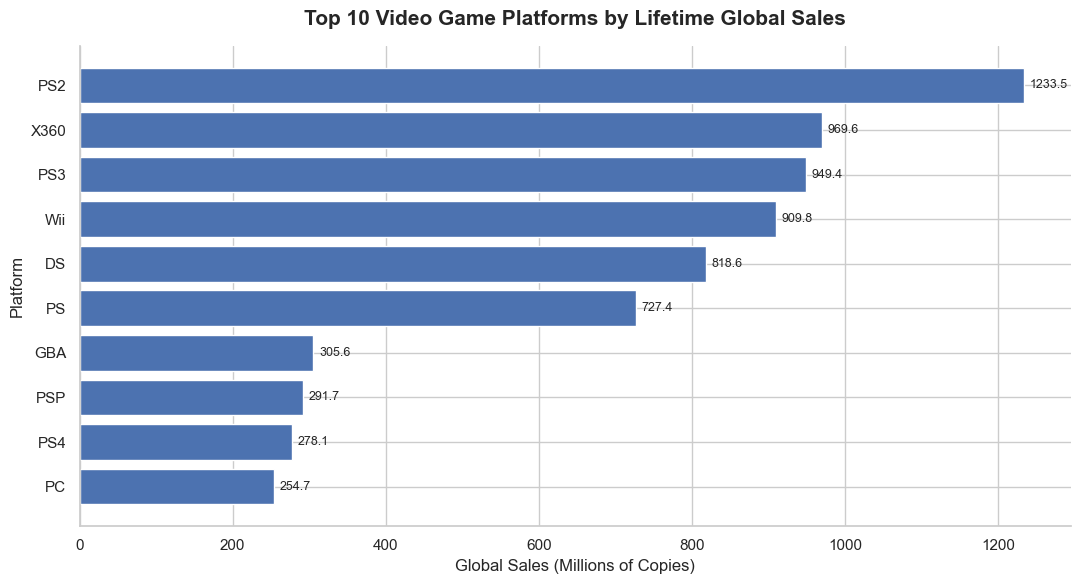

In [85]:
fig, ax = plt.subplots(figsize=(11, 6))

plot_data = top_platforms_lifetime.sort_values(
    "lifetime_global_sales",
    ascending=True
)

bars = ax.barh(
    plot_data["platform"],
    plot_data["lifetime_global_sales"]
)

ax.bar_label(
    bars,
    fmt="%.1f",
    padding=4,
    fontsize=9
)

ax.set_title(
    "Top 10 Video Game Platforms by Lifetime Global Sales",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Global Sales (Millions of Copies)")
ax.set_ylabel("Platform")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### Key Takeaway
The PlayStation 2 had the highest lifetime global sales at approximately **1,233.5 million copies**, placing it well ahead of every other platform in the dataset. The Xbox 360, PlayStation 3, and Wii formed a second group with relatively similar lifetime totals of roughly **910–970 million copies**, while the Nintendo DS followed at **818.6 million**.

The large gap between the PlayStation 2 and the remaining platforms suggests that it combined strong software sales with a long and successful market lifespan. However, lifetime sales alone do not show whether it led the market in the greatest number of individual years, so annual performance must also be examined.

### 2. Sales Relative to Active Lifespan

Lifetime totals can favour platforms with more active years. Average annual global sales provide a second view by measuring the typical sales volume generated during the years in which each platform recorded sales.

In [86]:
platform_annual_performance = (
    platform_summary.sort_values(
        "average_annual_sales",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

platform_annual_performance[
    [
        "platform",
        "active_years",
        "lifetime_global_sales",
        "average_annual_sales",
        "peak_year",
        "peak_year_sales"
    ]
]

,platform,active_years,lifetime_global_sales,average_annual_sales,peak_year,peak_year_sales
0,PS2,12,"1,233.46",102.79,2004,211.78
1,Wii,10,909.81,90.98,2009,210.44
2,PS3,11,949.35,86.30,2011,159.37
3,X360,12,969.60,80.80,2010,171.05
4,PS,10,727.39,72.74,1998,169.58
5,PS4,4,278.07,69.52,2015,115.30
6,DS,12,818.62,68.22,2007,149.36
7,3DS,6,246.27,41.05,2011,62.53
8,GBA,8,305.62,38.20,2002,74.38
9,XOne,4,141.06,35.27,2015,57.66


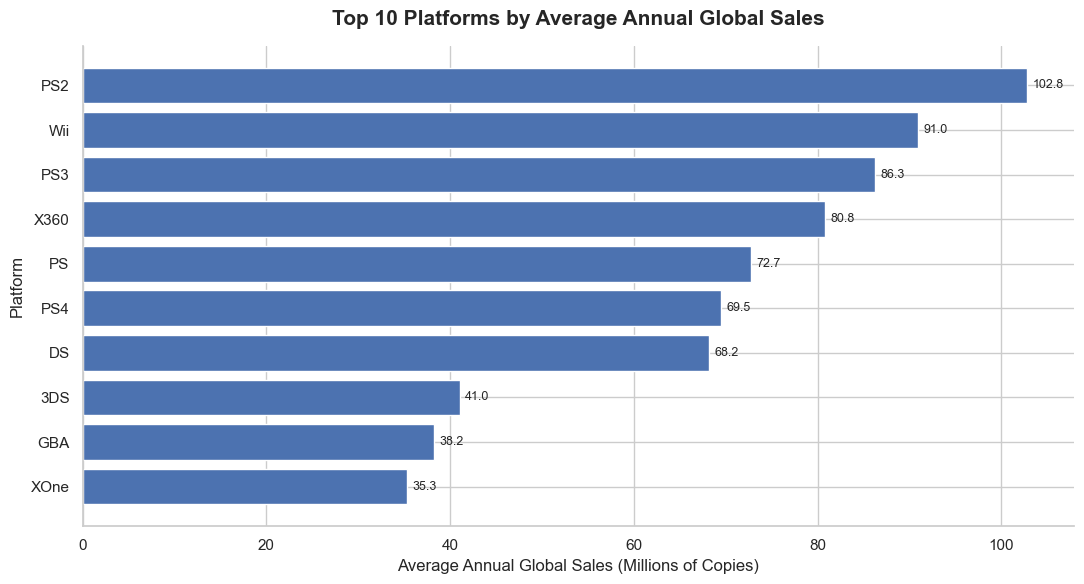

In [87]:
fig, ax = plt.subplots(figsize=(11, 6))

plot_data = platform_annual_performance.sort_values(
    "average_annual_sales",
    ascending=True
)

bars = ax.barh(
    plot_data["platform"],
    plot_data["average_annual_sales"]
)

ax.bar_label(
    bars,
    fmt="%.1f",
    padding=4,
    fontsize=9
)

ax.set_title(
    "Top 10 Platforms by Average Annual Global Sales",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Average Annual Global Sales (Millions of Copies)")
ax.set_ylabel("Platform")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### Key Takeaway

The PlayStation 2 also ranked first in average annual global sales, reaching approximately **102.8 million copies per active year**. The Wii followed at **91.0 million**, while the PlayStation 3 and Xbox 360 recorded similarly strong averages of **86.3 million** and **80.8 million**, respectively.

Because the PlayStation 2 ranked first in both lifetime sales and average annual sales, its overall lead was not explained only by a long market lifespan. It also maintained exceptionally strong yearly software sales. The Wii’s second-place position is also notable because it ranked below several platforms in lifetime sales but performed more strongly when sales were evaluated relative to active years.

### 3. Annual Sales Trajectories of Major Platforms

The top platforms by lifetime sales are compared across time to show their growth, peak, and decline. The chart emphasizes that platform leadership occurred in overlapping generations rather than remaining with one platform throughout the complete period.

In [88]:
major_platforms = (
    platform_summary.nlargest(10, "lifetime_global_sales")["platform"]
                    .tolist()
)

major_platform_year_sales = (
    platform_year_sales[
        platform_year_sales["platform"].isin(major_platforms)
    ]
    .copy()
)

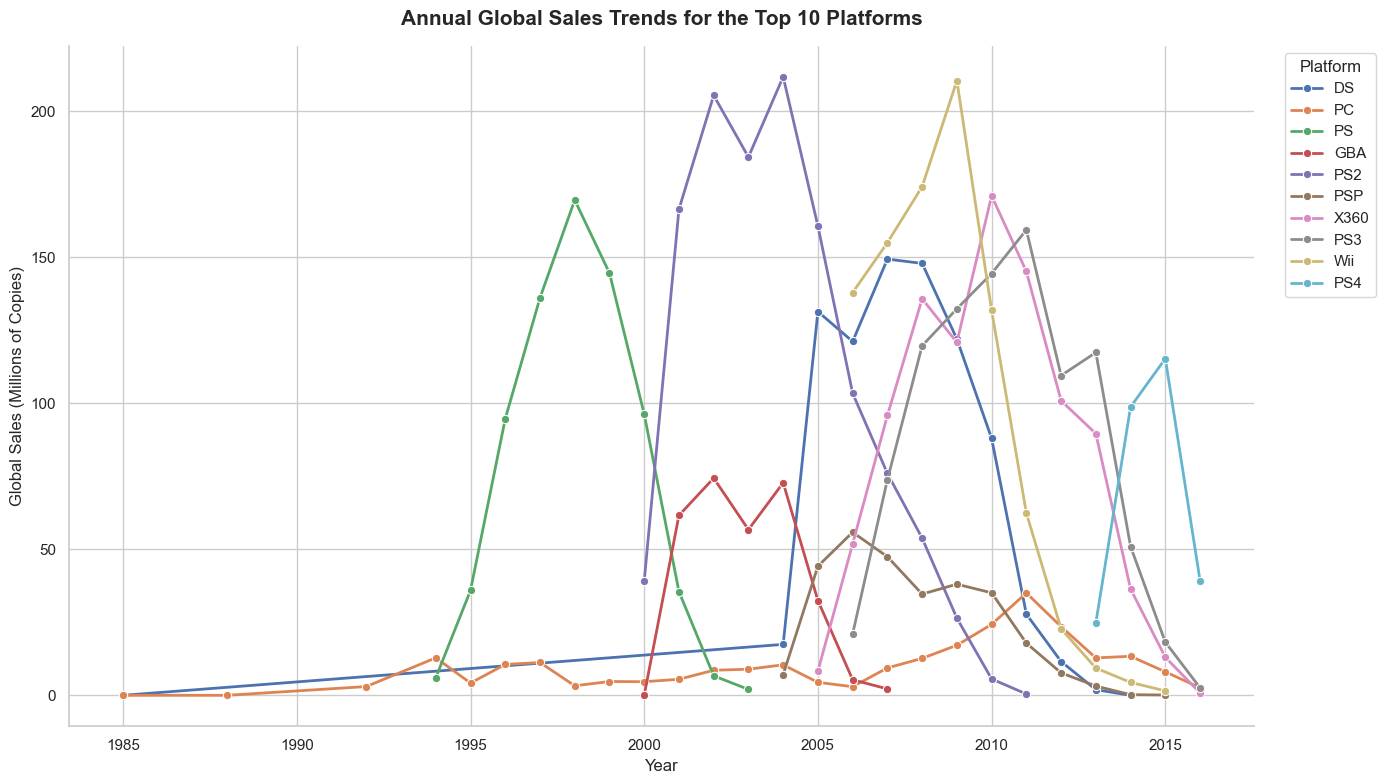

In [89]:
fig, ax = plt.subplots(figsize=(14, 8))

sns.lineplot(
    data=major_platform_year_sales,
    x="year",
    y="global_sales",
    hue="platform",
    marker="o",
    linewidth=2,
    ax=ax
)

ax.set_title(
    "Annual Global Sales Trends for the Top 10 Platforms",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Year")
ax.set_ylabel("Global Sales (Millions of Copies)")
ax.legend(
    title="Platform",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### Key Takeaway

The annual sales trajectories show a clear pattern of platform generations replacing one another over time. The original PlayStation peaked in the late 1990s, followed by the PlayStation 2 in the early 2000s. The Nintendo DS and Wii then became major leaders during the mid-to-late 2000s, while the Xbox 360 and PlayStation 3 remained strong into the early 2010s. The PlayStation 4 became the most prominent newer platform near the end of the dataset.

The PlayStation 2 recorded the highest single-year sales total among the major platforms at slightly above **210 million copies**, while the Wii reached a similarly large peak around **2009**. Most platforms experienced a rapid rise, a short peak period, and then a noticeable decline as newer systems entered the market. This supports the conclusion that platform dominance was temporary and shifted repeatedly between hardware generations.

### 4. Frequency of Annual Market Leadership

Lifetime sales do not reveal how often a platform finished first within an individual year. The following comparison counts the number of years in which each platform recorded the highest annual global sales.

In [90]:
yearly_leaders_table = (
    yearly_platform_leaders.rename(
        columns={
            "year": "Year",
            "platform": "Leading Platform",
            "global_sales": "Platform Sales",
            "yearly_global_sales": "Total Market Sales",
            "market_share_pct": "Market Share (%)",
            "game_count": "Games Released"
        }
    )
)

yearly_leaders_table

,Year,Leading Platform,Platform Sales,Total Market Sales,Market Share (%),Games Released
0,1980,2600,11.38,11.38,100.00,9
1,1981,2600,35.77,35.77,100.00,46
2,1982,2600,28.86,28.86,100.00,36
3,1983,NES,10.96,16.79,65.28,6
4,1984,NES,50.09,50.36,99.46,13
5,1985,NES,53.44,53.94,99.07,11
6,1986,NES,36.41,37.07,98.22,19
7,1987,NES,19.76,21.74,90.89,10
8,1988,NES,45.01,47.22,95.32,11
9,1989,GB,64.98,73.45,88.47,10


In [91]:
platform_leadership_counts = (
    yearly_platform_leaders.groupby("platform", as_index=False)
                           .agg(
                               years_as_leader=("year", "count"),
                               first_leading_year=("year", "min"),
                               last_leading_year=("year", "max"),
                               average_leader_share=(
                                   "market_share_pct",
                                   "mean"
                               )
                           )
                           .sort_values(
                               ["years_as_leader", "average_leader_share"],
                               ascending=[False, False]
                           )
                           .reset_index(drop=True)
)

platform_leadership_counts

,platform,years_as_leader,first_leading_year,last_leading_year,average_leader_share
0,NES,6,1983,1988,91.37
1,PS,6,1995,2000,54.57
2,SNES,5,1990,1994,55.58
3,PS2,5,2001,2005,47.97
4,Wii,4,2006,2009,27.27
5,2600,3,1980,1982,100.00
6,PS4,3,2014,2016,42.75
7,PS3,3,2011,2013,30.97
8,GB,1,1989,1989,88.47
9,X360,1,2010,2010,28.49


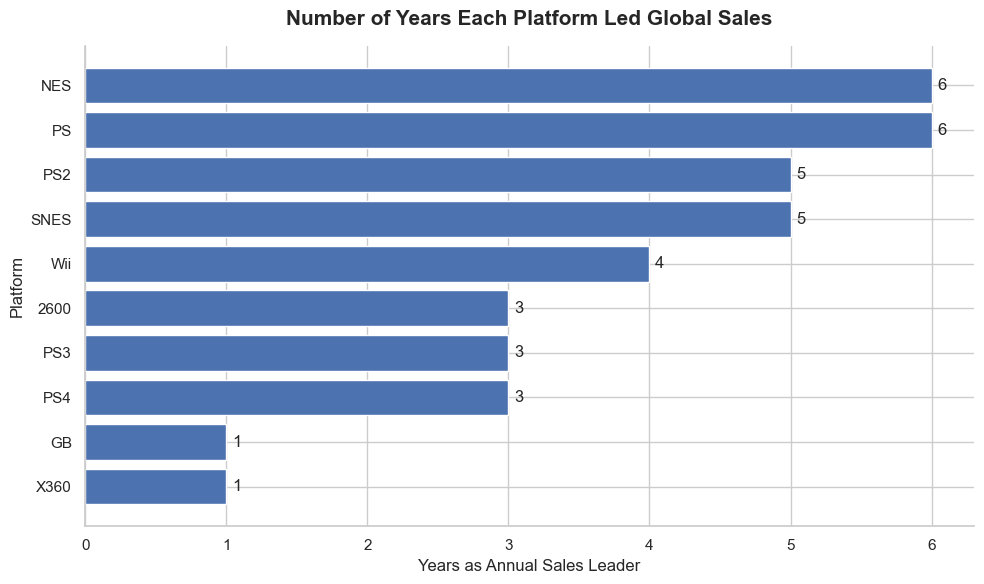

In [92]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_data = platform_leadership_counts.sort_values(
    "years_as_leader",
    ascending=True
)

bars = ax.barh(
    plot_data["platform"],
    plot_data["years_as_leader"]
)

ax.bar_label(
    bars,
    fmt="%d",
    padding=4
)

ax.set_title(
    "Number of Years Each Platform Led Global Sales",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Years as Annual Sales Leader")
ax.set_ylabel("Platform")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### Key Takeaway

The NES and original PlayStation were the most frequent annual market leaders, with each ranking first in global sales for **six years**. The PlayStation 2 and SNES followed closely with **five leading years**, while the Wii led for **four years**.

These results show that the platform with the highest lifetime sales was not necessarily the platform that led the market most often. Although the PlayStation 2 had the largest lifetime and average annual sales totals, the NES and original PlayStation each held the top annual position for a greater number of years. Platform dominance therefore depended not only on total sales, but also on how consistently a system remained ahead of its competitors across different market periods.

### 5. Timeline of Annual Platform Leadership

Each year is assigned to the platform with the highest global sales. The timeline shows the order in which platforms became market leaders and whether their leadership was sustained or interrupted.

In [93]:
leader_order = (
    yearly_platform_leaders["platform"]
    .drop_duplicates()
    .tolist()
)

leader_to_position = {
    platform: position
    for position, platform in enumerate(leader_order)
}

leadership_timeline = yearly_platform_leaders.copy()
leadership_timeline["position"] = (
    leadership_timeline["platform"].map(leader_to_position)
)

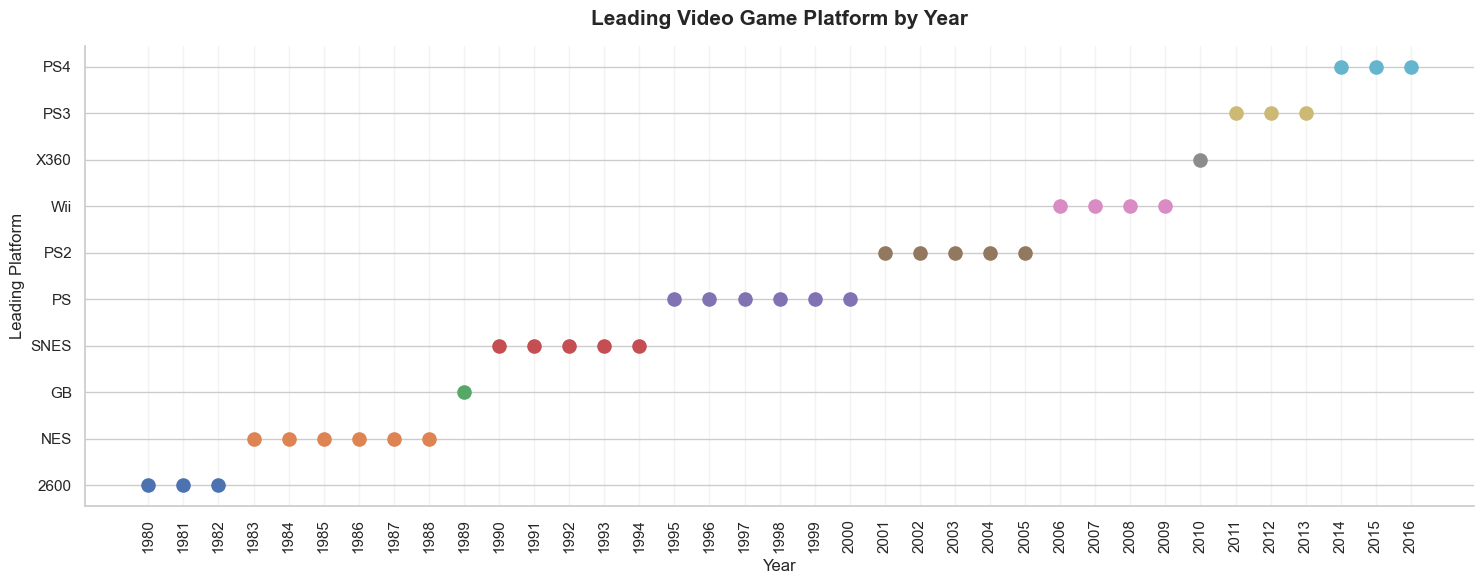

In [94]:
fig, ax = plt.subplots(figsize=(15, 6))

for platform in leader_order:
    platform_data = leadership_timeline[
        leadership_timeline["platform"] == platform
    ]

    ax.scatter(
        platform_data["year"],
        platform_data["position"],
        s=90,
        label=platform
    )

ax.set_yticks(range(len(leader_order)))
ax.set_yticklabels(leader_order)
ax.set_xticks(leadership_timeline["year"])
ax.tick_params(axis="x", rotation=90)

ax.set_title(
    "Leading Video Game Platform by Year",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Year")
ax.set_ylabel("Leading Platform")
ax.grid(axis="x", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### Key Takeaway

The leadership timeline shows a clear sequence of dominant platform generations. The Atari 2600 led from **1980 to 1982**, followed by the NES from **1983 to 1988**. After a one-year lead by the Game Boy in **1989**, the SNES led from **1990 to 1994**, followed by the original PlayStation from **1995 to 2000**.

The PlayStation 2 then led from **2001 to 2005**, before the Wii took over from **2006 to 2009**. Leadership shifted briefly to the Xbox 360 in **2010**, then to the PlayStation 3 from **2011 to 2013**, and finally to the PlayStation 4 from **2014 to 2016**.

Overall, the chart shows that platform dominance changed in distinct stages, with most leading systems holding the top position for several consecutive years before being replaced by a newer generation.

### 6. Strength of Annual Market Leadership

Finishing first does not necessarily mean controlling most of the market. The annual market share of the leading platform measures how concentrated or competitive the market was in each year.

A 50% reference line is included to distinguish years in which the leading platform alone accounted for more than half of recorded global sales.

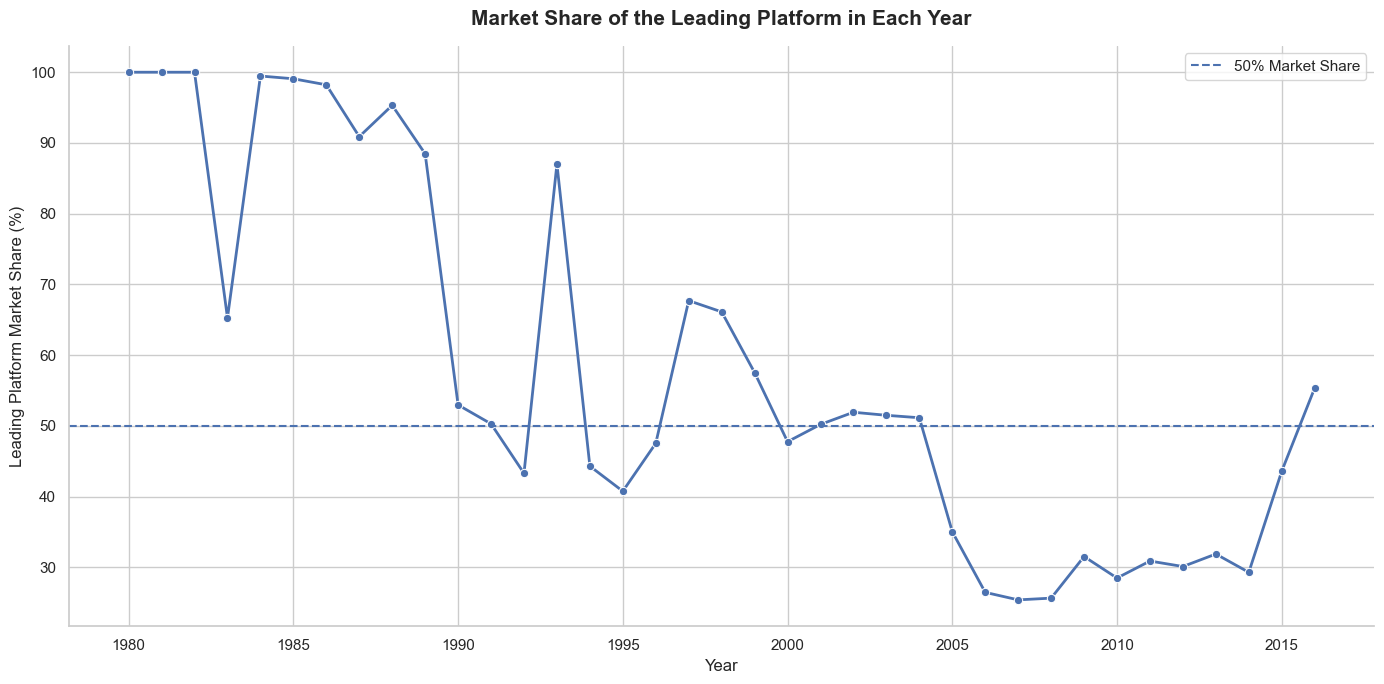

In [96]:
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=yearly_platform_leaders,
    x="year",
    y="market_share_pct",
    marker="o",
    linewidth=2,
    ax=ax
)

ax.axhline(
    50,
    linestyle="--",
    linewidth=1.5,
    label="50% Market Share"
)

ax.set_title(
    "Market Share of the Leading Platform in Each Year",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Year")
ax.set_ylabel("Leading Platform Market Share (%)")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### Key Takeaway

The strength of annual platform leadership decreased substantially over time. During the early 1980s, the leading platform accounted for nearly **100% of recorded annual global sales**, indicating a highly concentrated market with limited competition.

From the 1990s onward, the leading platform’s share generally declined and became more variable. Leadership was often close to the **50% threshold** during the late 1990s and early 2000s, before falling to approximately **25%–35%** for much of the period after 2005.

This suggests that the video game platform market became increasingly competitive as more systems overlapped within the same years. Later annual leaders still ranked first in global sales, but they controlled a much smaller portion of the total market than earlier leaders.

### 7. Margin Between the First- and Second-Place Platforms

The leader's market share indicates concentration, but it does not directly show how close the nearest competitor was. The sales margin between the first- and second-place platforms is calculated for every year.

In [97]:
yearly_ranked_platforms = platform_market_share.copy()

yearly_ranked_platforms["annual_rank"] = (
    yearly_ranked_platforms.groupby("year")["global_sales"]
                           .rank(method="first", ascending=False)
)

top_two_by_year = (
    yearly_ranked_platforms[
        yearly_ranked_platforms["annual_rank"].isin([1, 2])
    ]
    .pivot(
        index="year",
        columns="annual_rank",
        values=["platform", "global_sales", "market_share_pct"]
    )
)

top_two_by_year.columns = [
    f"{measure}_{int(rank)}"
    for measure, rank in top_two_by_year.columns
]

top_two_by_year = top_two_by_year.reset_index().rename(
    columns={
        "platform_1": "leader",
        "platform_2": "runner_up",
        "global_sales_1": "leader_sales",
        "global_sales_2": "runner_up_sales",
        "market_share_pct_1": "leader_share_pct",
        "market_share_pct_2": "runner_up_share_pct"
    }
)

top_two_by_year["sales_margin"] = (
    top_two_by_year["leader_sales"]
    - top_two_by_year["runner_up_sales"]
)

top_two_by_year["share_margin_pct_points"] = (
    top_two_by_year["leader_share_pct"]
    - top_two_by_year["runner_up_share_pct"]
)

top_two_by_year.head()

,year,leader,runner_up,leader_sales,runner_up_sales,leader_share_pct,runner_up_share_pct,sales_margin,share_margin_pct_points
0,1980,2600,NaN,11.38,NaN,100.00,NaN,NaN,NaN
1,1981,2600,NaN,35.77,NaN,100.00,NaN,NaN,NaN
2,1982,2600,NaN,28.86,NaN,100.00,NaN,NaN,NaN
3,1983,NES,2600,10.96,5.83,65.28,34.72,5.13,30.55
4,1984,NES,2600,50.09,0.27,99.46,0.54,49.82,98.93


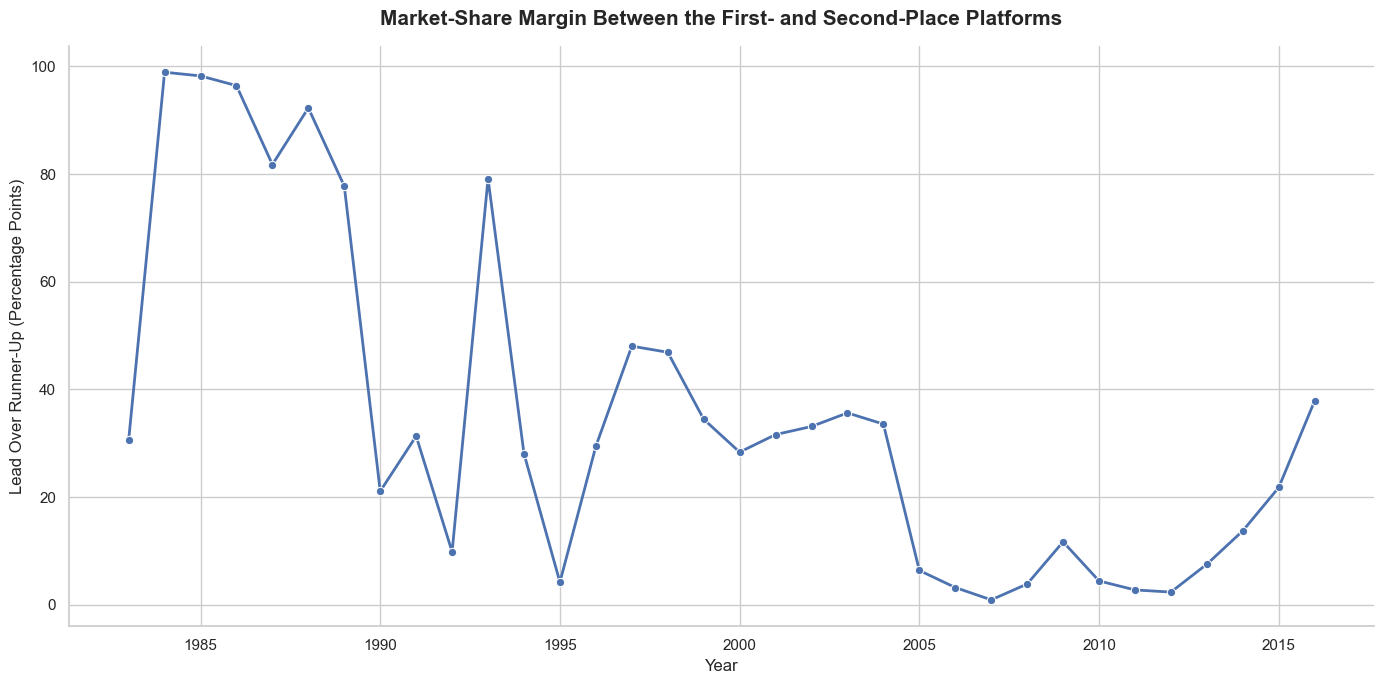

In [98]:
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=top_two_by_year,
    x="year",
    y="share_margin_pct_points",
    marker="o",
    linewidth=2,
    ax=ax
)

ax.set_title(
    "Market-Share Margin Between the First- and Second-Place Platforms",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Year")
ax.set_ylabel("Lead Over Runner-Up (Percentage Points)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### Key Takeaway

The gap between the leading and second-place platforms was much larger during the earlier years of the dataset. In the mid-to-late 1980s, the annual leader often finished more than **75 percentage points** ahead of the runner-up, indicating that sales were heavily concentrated around one dominant platform.

The margin generally narrowed over time. By the mid-2000s and early 2010s, the first-place platform was often less than **10 percentage points** ahead of its closest competitor, with the smallest gap occurring around **2007**. This confirms that later market leaders faced much stronger competition and often won the annual sales ranking by only a small margin.

Although the lead began to widen again near the end of the dataset, it remained far below the extreme gaps observed during the 1980s. Overall, the chart supports the conclusion that the platform market became more competitive as multiple major systems increasingly overlapped.

## Final Interpretation

Platform dominance changed in clear generational stages rather than remaining with one system throughout the market’s history. The annual leadership timeline shows a sequence from the Atari 2600 in the early 1980s, to the NES, SNES, original PlayStation, PlayStation 2, Wii, Xbox 360, PlayStation 3, and finally the PlayStation 4. Most leading platforms remained in first place for several consecutive years before being replaced by a newer generation.

The PlayStation 2 was the strongest platform overall by sales volume. It recorded the highest lifetime global sales at approximately **1,233.5 million copies** and the highest average annual sales at about **102.8 million copies per active year**. However, it did not lead the market for the greatest number of years. The NES and original PlayStation each ranked first for **six years**, compared with **five years** for the PlayStation 2 and SNES. This shows that lifetime sales, yearly sales intensity, and duration of annual leadership represent different aspects of dominance.

The annual sales trajectories further show that platform performance generally followed a rise, peak, and decline pattern. As newer systems entered the market, sales shifted away from older platforms rather than remaining concentrated around one permanent leader. The PlayStation 2 reached the highest single-year total among the major platforms, but later systems such as the Wii, Xbox 360, PlayStation 3, and PlayStation 4 became dominant during their own periods.

The strength of dominance also changed over time. Early leaders often controlled nearly all recorded annual sales and finished far ahead of the second-place platform. From the mid-2000s onward, the leading platform usually held a much smaller market share and frequently finished fewer than **10 percentage points** ahead of its closest competitor. This indicates that the market became increasingly competitive as more major platforms overlapped.

Overall, platform dominance was temporary, cyclical, and increasingly contested. Earlier market periods were often controlled by one clearly dominant system, while later periods were divided among several strong competitors. The PlayStation 2 achieved the greatest overall sales performance, but the NES and original PlayStation maintained annual leadership most frequently, demonstrating that no single platform was dominant by every measure.